# 일반화 선형 회귀 (GLM) 
- 정규분포를 따르지 않는 종속변수에 적절한 함수를 적용하여 예측변수에 따라 선형적으로 변화하도록 하는 회귀모델 기법 
- 종속변수에 적용하는 함수 : 연결함수 
   
### 연결함수 종류
1. Y가 포아송 분포일 때 : log 
    - Y가 개수/ 빈도를 나타내는 경우 
    - log(Y) = B(절편)X(독립변수들)
2. Y가 베르누이, 다항회귀 : Logit
    - 다항 로지스틱 회귀
    - log( Y/(1-Y) ) = BX
3. Y가 이항분포 : logit
    - Y가 0 또는 1인 경우 (로지스틱 회귀)
    - log( Y/(n-Y) ) = BX

In [2]:
import statsmodels.api as sm

# 6가지 살충제 별로 살아남은 회충 수 
# 데이터 불러오기
insect = sm.datasets.get_rdataset("InsectSprays", "datasets").data
insect

,count,spray
0,10,A
1,7,A
2,20,A
3,14,A
4,14,A
...,...,...
67,10,F
68,26,F
69,26,F
70,24,F


# 로지스틱 회귀 
- 최대우도추정을 사용하여 모델을 적합 : 예상 로그 오즈비가 관찰된 결과를 가장 잘 설명하는 모델을 찾는다
- 잔차분석 불가능 

#### 장점  : 모델 구현이 쉽고 계산이 빨라 효율적이다. 모델을 해석하기 쉽다
#### 단점  : 이상치에 민감하고, 표본의 크기가 너무 작으면 추정치가 불안정할 수 있다.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
# 데이터 로드
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 학습/평가 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 특성 스케일링 + 로지스틱 회귀 모델 파이프라인 구성
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)  # 파라미터 C값이 높아질수록 모델 복잡성이 높아진다. (반대)
model.fit(X_train_scaled, y_train)

# 예측
y_pred = model.predict(X_test_scaled)

# 결과 출력
print("정확도 (Accuracy):", accuracy_score(y_test, y_pred))
print("\n혼동행렬 (Confusion Matrix):\n", confusion_matrix(y_test, y_pred))
print("\n분류 리포트 (Classification Report):\n", classification_report(y_test, y_pred))

정확도 (Accuracy): 0.9824561403508771

혼동행렬 (Confusion Matrix):
 [[41  1]
 [ 1 71]]

분류 리포트 (Classification Report):
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [14]:
# 해석 
# 다른 특성들의 값은 동일한 상태에서 해당 변수가 한단위 증가하면 증가후 Y(1이 될 확률)의 오즈가 증가 전 Y의 오즈의 exp(회귀계수)배 된다. 
# 오즈비가 1보다 크면 해당 변수가 증가할 때 y의 오즈가 높아지는 양의 인과관계가 있음을 알 수 있다.

In [29]:
# 회귀 계수 확인
import pandas as pd
import numpy as np

# 계수 및 승산비 계산
coefs = model.coef_[0]
odds_ratios = np.exp(coefs)

result = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefs,
    'Odds Ratio': odds_ratios
})

result = result.sort_values(by='Odds Ratio', ascending=False)

print("로지스틱 회귀 계수 및 승산비 (odds ratio):")
print(result[['Feature', 'Coefficient', 'Odds Ratio']])
print("mean compactness가 한 단위 증가하면 오즈가 1.92배 된다. 92% 증가한다.이는 양의 인과관계가 있음을 알 수 있다.")
print("여자0 , 남자 1,여자에서 남자로 바뀌었을 때의 오즈가 //// 배 된다. ")
print("약 72% 감소한다. 오즈비는 0.28배 된다.")

로지스틱 회귀 계수 및 승산비 (odds ratio):
                    Feature  Coefficient  Odds Ratio
5          mean compactness     0.653627    1.922501
15        compactness error     0.642724    1.901653
19  fractal dimension error     0.435616    1.545915
18           symmetry error     0.358784    1.431588
11            texture error     0.251148    1.285500
9    mean fractal dimension     0.193609    1.213621
16          concavity error     0.171287    1.186832
25        worst compactness     0.043814    1.044788
14         smoothness error    -0.158133    0.853736
29  worst fractal dimension    -0.172037    0.841948
8             mean symmetry    -0.172986    0.841150
4           mean smoothness    -0.207718    0.812436
17     concave points error    -0.447084    0.639490
2            mean perimeter    -0.471408    0.624123
0               mean radius    -0.505070    0.603463
12          perimeter error    -0.537215    0.584374
3                 mean area    -0.538737    0.583485
1              

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 불러오기
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 변수 개수 줄이기 (고유 변수만 일부 선택)  공선성 확인 및 제거 (강력 추천) -> VIF 계산하기 
selected_features = [
    'mean radius', 'mean texture', 'mean smoothness',
    'mean concavity', 'mean concave points'
]
X_train_reduced = X_train[selected_features]

# 표준화
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_reduced), columns=selected_features
)

# 상수항 추가
X_train_scaled_const = sm.add_constant(X_train_scaled)

# 로지스틱 회귀 적합
logit_model = sm.Logit(y_train, X_train_scaled_const)
result = logit_model.fit(disp=False)

# 회귀 요약 출력
print(result.summary())

# 승산비 계산
summary_df = pd.DataFrame({
    'Feature': result.params.index,
    'Coefficient': result.params.values,
    'Odds Ratio': np.exp(result.params.values),
    'p-value': result.pvalues.values
})

print("\n회귀 계수 및 승산비:")
print(summary_df)

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  455
Model:                          Logit   Df Residuals:                      449
Method:                           MLE   Df Model:                            5
Date:                Mon, 25 Aug 2025   Pseudo R-squ.:                  0.8038
Time:                        13:42:45   Log-Likelihood:                -58.997
converged:                       True   LL-Null:                       -300.69
Covariance Type:            nonrobust   LLR p-value:                3.075e-102
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.6988      0.249      2.807      0.005       0.211       1.187
mean radius            -4.0928      0.944     -4.335      0.000      -5.943      -2.242
mean texture    

### 우도비 검정 
- 우도비 검정 : 로그우도비 통계량으로 모델 유효성 확인 
- 로그 우도비 : -2 X ( 상수항만 있는 모형의 최대로그가능도 - 해당모형의 최대로그가능도 )
   
- 귀무가설 : null model 최대가능도와 full model의 최대로그 가능도는 차이가 없다 
- 대립가설 : null model 최대가능도가 full model의 최대로그 가능도보다 크다 (좌측 단측검정)

In [18]:
# LLR 로그 우도비 
print(result.llnull)  # null model 최대가능도
print(result.llf)     # full model 최대가능도

-300.6901749481325
-58.99682642584578


In [21]:
#석규님

483.38669704457345

In [47]:
result.llr_pvalue   # 로그우도비 검정 p-value
# 해당 모델은 통계적으로 유의하다고 할 수 있다. 

3.075146400131453e-102

In [46]:
result.prsquared   # 결정계수 

0.8037952971492254

### 회귀계수 검정 
- 회귀계수가 0인지 아닌지를 검정하여 회귀계수의 유효성을 확인해야한다. - Z분포
- 또는 통계량을 제곱한 왈드 검정 통계량 : 카이제곱 분포로 회귀계수 유효성 검정 가능

In [48]:
# 회귀계수 유의성 확인 
# mean concavity, mean concave points가 0.05보다 크므로 유의하지 않다. 

# 다항 로지스틱 회귀 : Y = 3개의 범주

In [69]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.datasets import load_iris

iris_raw = load_iris()
X = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
y = pd.Series(iris_raw.target)  # 0=setosa, 1=versicolor, 2=virginica

# 2. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# 3. 표준화 (Z-score scaling)
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_test_z = scaler.transform(X_test)

# 4. 다항 로지스틱 회귀 모델 학습
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr.fit(X_train_z, y_train)

# 5. 예측
y_pred_lr = lr.predict(X_test_z)

# 6. 성능 평가
print(f"로지스틱 회귀 정확도: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\n분류 리포트:\n")
print(classification_report(y_test, y_pred_lr, target_names=iris_raw.target_names))

로지스틱 회귀 정확도: 0.9333

분류 리포트:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [75]:
import numpy as np
import pandas as pd

# 계수 확인
coef = lr.coef_  # shape: (n_classes, n_features)
odds_ratios = np.exp(coef)  # 오즈비로 해석

# 보기 좋게 출력
pd.DataFrame(odds_ratios, columns=X.columns, index=list(iris_raw.target_names))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.336602,2.784111,0.165486,0.185413
versicolor,1.709411,0.697634,0.814981,0.445587
virginica,1.737949,0.514856,7.414665,12.103937


# 포아송 회귀 : Y가 빈도 데이터
- Y가 포아송 분포를 따른다면
- 동일한 길이의 두 구간에서 사건 발생 확률은 동일하고, 서로 독립이다. 
- 같은 구간에 두개이상의 사건이 나올 확률은 0이다. 

### 포아송 회귀 모델의 적합성 확인
    1. Pearson 통계량 사용
        - 카이제곱 분포(잔차의 자유도) 
        - H0 : 회귀 모델이 유효하다 
        - H1 : 회귀모델이 유효하지 않다. 
    2. Deviance 통계량 사용
        - 카이제곱 분포(잔차의 자유도) 
        - H0 : 회귀 모델이 유효하다 
        - H1 : 회귀모델이 유효하지 않다. 

In [9]:
import koreanize_matplotlib
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson


# 정신과 환자의 자살 시도 횟수 데이터를 다룬 카운트형 데이터셋
# sumY(종속변수) : 치료시작 후 8주 동안의 발작 횟수 
# Base : 치료시작 전 8주 동안의 발작 횟수
# Age : 나이
# Trt : 치료 방법 (2개 범주)
df = pd.read_csv("breslow.csv")
df.head()

,ID,Y1,Y2,Y3,Y4,Base,Age,Trt,Ysum,sumY,Age10,Base4
0,104,5,3,3,3,11,31,placebo,14,14,3.1,2.75
1,106,3,5,3,3,11,30,placebo,14,14,3.0,2.75
2,107,2,4,0,5,6,25,placebo,11,11,2.5,1.50
3,114,4,4,1,4,8,36,placebo,13,13,3.6,2.00
4,116,7,18,9,21,66,22,placebo,55,55,2.2,16.50


In [10]:
seizure = df[['Base', 'Age', 'Trt','sumY']]
seizure.describe()

,Base,Age,sumY
count,59.000000,59.000000,59.000000
mean,31.220339,28.338983,33.050847
std,26.877158,6.301642,45.584111
min,6.000000,18.000000,0.000000
25%,12.000000,23.000000,11.500000
50%,22.000000,28.000000,16.000000
75%,41.000000,32.000000,36.000000
max,151.000000,42.000000,302.000000


In [7]:
# Base , sumY 모두 평균보다 중앙값이 작기 때문에 오른쪽으로 긴 편향된 분포를 가진다.

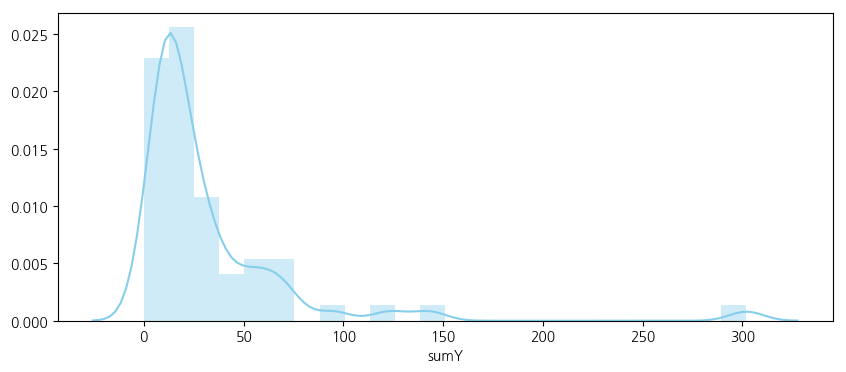

In [13]:
# 포아송 분포 여부 시각화
plt.figure(figsize=(10, 4))
sns.distplot(seizure['sumY'], hist=True, color='skyblue', label='sumY')
plt.show()

In [16]:
import statsmodels.formula.api as smf

# 변수 전처리
seizure['sumY'] = seizure['sumY'].astype(int)  # 종속변수는 반드시 정수형

# 포뮬러: 종속변수 ~ 독립변수들
formula = 'sumY ~ Base + Age + Trt'

# 포아송 회귀 모델 적합
poisson_model = smf.glm(formula=formula, data=seizure, family=sm.families.Poisson()).fit()

# 결과 요약
poisson_model.summary()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                   sumY   No. Observations:                   59
Model:                            GLM   Df Residuals:                       55
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -421.35
Date:                Mon, 25 Aug 2025   Deviance:                       559.44
Time:                        12:58:43   Pearson chi2:                     647.
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.9488      0.136     14.370      0.000       1.683       2.215
Trt[T.progabide]    -0.1527      0.048     -3.194      0.001      -0.246      -0.059
Base                 0.0227      0.001     44.476      0.000       0.022       0.024
Age                  0.0227      0.004      5.651      0.000       0.015       0.031
====================================================================================
"""

In [50]:
# 포아송 회귀에 사용되는 주거침입 사건 수 (number of affairs) 데이터

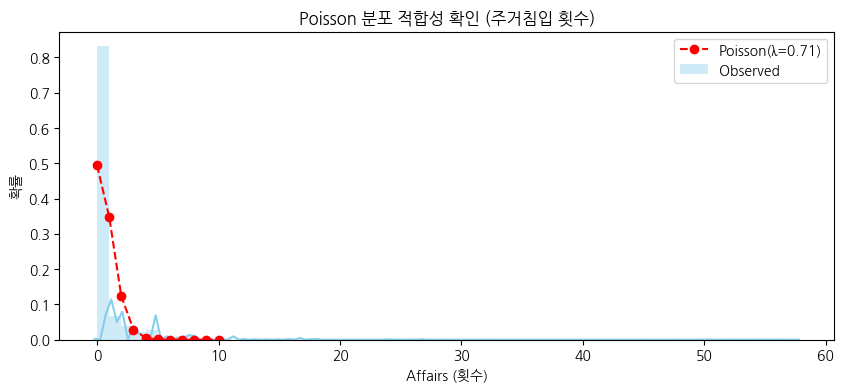

In [57]:
import koreanize_matplotlib
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson

# 데이터 불러오기
data = sm.datasets.fair.load_pandas().data

# 종속변수: 바람을 피운 횟수 (count 데이터)
y = data['affairs']

# 포아송 분포 여부 시각화
plt.figure(figsize=(10, 4))
sns.distplot(y, bins=range(0, 11), hist=True, color='skyblue', label='Observed')

# 이론적 포아송 분포
mu = y.mean()  # 람다 
x_vals = range(0, 11)
poisson_probs = poisson.pmf(x_vals, mu)
plt.plot(x_vals, poisson_probs, marker='o', linestyle='dashed', color='red', label='Poisson(λ=%.2f)' % mu)
plt.title("Poisson 분포 적합성 확인 (주거침입 횟수)")
plt.xlabel("Affairs (횟수)")
plt.ylabel("확률")
plt.legend()
plt.show()

In [60]:
import statsmodels.formula.api as smf

# 변수 전처리
data['affairs'] = data['affairs'].astype(int)  # 종속변수는 반드시 정수형
data['rate_marriage'] = data['rate_marriage'].astype(float)

# 포뮬러: 종속변수 ~ 독립변수들
formula = 'affairs ~ age + yrs_married + children + religious + educ + rate_marriage'

# 포아송 회귀 모델 적합
poisson_model = smf.glm(formula=formula, data=data, family=sm.families.Poisson()).fit()

# 결과 요약
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                affairs   No. Observations:                 6366
Model:                            GLM   Df Residuals:                     6359
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8046.4
Date:                Tue, 22 Apr 2025   Deviance:                       13051.
Time:                        15:19:49   Pearson chi2:                 3.39e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3287
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.6401      0.159     22.898

In [61]:
# 계수, 승산비 출력
summary_df = pd.DataFrame({
    'Coefficient': poisson_model.params,
    'Odds Ratio': np.exp(poisson_model.params),
    'p-value': poisson_model.pvalues
})
print("\n포아송 회귀 계수 및 승산비:")
print(summary_df)
# 해석 
# 다른 특성들의 값은 동일한 상태에서 해당 변수가 한단위 증가하면 증가후 빈도수가 exp(회귀계수)배 증가한다. 


포아송 회귀 계수 및 승산비:
               Coefficient  Odds Ratio        p-value
Intercept         3.640057   38.094001  4.812024e-116
age              -0.022467    0.977784   1.416789e-04
yrs_married      -0.063765    0.938225   5.857943e-21
children         -0.025148    0.975165   2.465798e-01
religious        -0.405261    0.666803   6.908005e-89
educ             -0.007943    0.992089   3.522034e-01
rate_marriage    -0.544212    0.580299  3.278245e-289


In [62]:
# 포아송 회귀 모델의 적합도 확인 : Pearson Chi2 통계량
poisson_model.pearson_chi2

33851.976548980994

# 모델 전체의 유의성 검정 

In [63]:
# 전체 모델 로그 가능도
ll_full = poisson_model.llf

# Null 모델 (절편만 사용)
null_model = sm.GLM.from_formula('affairs ~ 1', data=data, family=sm.families.Poisson()).fit()
ll_null = null_model.llf

# 우도비 통계량 및 p-value
LR_stat = 2 * (ll_full - ll_null)
df_diff = poisson_model.df_model  # 자유도 차이 = 독립변수 수
p_value = chi2.sf(LR_stat, df_diff)

print(f"우도비 통계량 (LR): {LR_stat:.4f}")
print(f"자유도: {df_diff}")
print(f"모델 전체 유의성 p-value: {p_value:.6f}")

우도비 통계량 (LR): 2536.8176
자유도: 6
모델 전체 유의성 p-value: 0.000000
